<a href="https://colab.research.google.com/github/fcastellanosp/MINE-4206_202510_AML/blob/main/Talleres/Taller%203/MINE_4206_202510_AML_Taller3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image](https://docs.google.com/uc?export=download&id=1NUy1Q-abpoV9XYK9qT9t8Mdhj3ZVlveO)

In [55]:
# Librerías Estándar
import re
import unicodedata
import inflect

# Manejo de Datos y Matemáticas
import numpy as np
import pandas as pd

# Visualización de Datos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from wordcloud import WordCloud, STOPWORDS

# Análisis Profundo de Datos (Perfilado)
from ydata_profiling import ProfileReport

# NLTK
import nltk
from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Scikit-learn y Skopt
import sklearn # Mantener importación general de sklearn si se usa en otras partes
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from skopt import BayesSearchCV
from skopt.space import Integer, Real


# **Taller 3**

- **Integrante 1:** Erich Giusseppe Soto Parada
- **Integrante 2:**

### **Problemática**:
Vivimos en una era digital en la que el acceso a la información es más rápido y amplio que nunca. A través de Internet, las personas pueden acceder a noticias y contenido de manera instantánea desde diversas plataformas: sitios web, redes sociales, blogs y aplicaciones móviles. Sin embargo, esta democratización de la información también ha traído consigo un desafío creciente: la proliferación de noticias falsas o fake news.

Las noticias falsas son informaciones intencionadamente distorsionadas, manipuladas o completamente inventadas, que se difunden con el fin de generar confusión, engañar a la audiencia, manipular la opinión pública o influir en decisiones políticas y sociales. El impacto de las fake news puede ser considerable. Por ejemplo, a nivel social, pueden crear pánico, generar desconfianza en las instituciones o alterar las percepciones de eventos importantes. A nivel político, las noticias falsas han sido utilizadas para influir en elecciones, sembrar división entre grupos sociales o tergiversar la realidad en temas de relevancia pública.

La magnitud del problema es tal que diversas organizaciones y gobiernos han comenzado a tomar medidas para combatir la desinformación, promoviendo el uso de tecnologías para detectar y verificar la veracidad de la información. En este contexto, el desarrollo de modelos automatizados que puedan identificar noticias falsas con alta precisión se ha convertido en una necesidad urgente.
El uso de técnicas de Procesamiento de Lenguaje Natural (NLP) y modelos de clasificación es crucial para poder abordar este reto de manera efectiva. Dado que el mercado y las plataformas digitales están saturados de información, el poder contar con un sistema automático que permita a los usuarios filtrar las noticias confiables de las falsas es esencial para mantener un entorno informativo saludable, preciso y responsable.

### **Objetivos:**

* Desarrollar una solución, basada en técnicas de procesamiento de lenguaje natural y machine learning, que facilite el análisis de información textual para la identificación de noticias falsas en español.

### **Conjunto de datos:**
> El conjunto de datos contiene noticias reales obtenidas mediante web scraping de sitios web de diferentes medios informativos. Además, incluye noticias falsas que fueron creadas modificando los datos de las noticias reales, así como noticias falsas generadas por inteligencia artificial.

El diccionario de los datos es el siguiente:
* **Label**. Es una etiqueta que indica si la noticia es verdadera o falsa. Toma el valor 1 si la noticia es verdadera y 0 si es falsa.
* **Título**. Contiene el titular de la noticia. Es una breve descripción que resume el contenido principal de la noticia.
* **Descripción**. Proporciona una descripción de la noticia, que se incluye detalles adicionales sobre el tema o los acontecimientos mencionados en la noticia.

Los datos se encuentran en el [repositorio de github](https://github.com/fcastellanosp/MINE-4206_202510_AML/blob/main/Talleres/Taller%203/Noticias_datos.xlsx).

### **Actividades a realizar:**
1.	Preparación de los textos utilizando el esquema de bolsa de palabras (BOW) con una pesado TF-IDF. Para este paso construir un pipeline que integre las transformaciones que se consideren adecuadas.
2.	Desarrollo de un modelo de clasificación que permita identificar si un texto corresponde a una noticia falsa o no. Para la construcción de este clasificador utilice Naïve Bayes (https://scikit-learn.org/stable/modules/naive_bayes.html).
3.	Evaluación del modelo con textos que no hayan sido utilizados para el aprendizaje.

### **Entregable:**

Notebook (*.ipynb y *.html) por la plataforma. El Notebook debe estar documentado con las justificaciones de las decisiones tomadas en cada paso del ciclo de machine learning y las respuestas a las preguntas planteadas en el apartado D. Además, deben ser visibles las ejecuciones de cada celda. Esta entrega debe realizarse en la sexta semana, en donde encontrarás un espacio para adjuntar los dos archivos.

> **NOTAS IMPORTANTES:**
> La rúbrica se encuentra disponible en bloque neón.
> - El archivo se debe subir a BloqueNeon en el apartado de 'Actividades' y debe ser en formato .ipynb, ejecutado. **Celda que no esté ejecutada no será evaluada.**
> - El Notebook debe estar documentado con las justificaciones de las decisiones tomadas en cada paso del ciclo de ML.
> - El nombre del archivo debe ser `taller_2_{Apellido_Nombre}_{Apellido_Nombre}` de cada integrante.

In [ ]:
test_val_alpha = 0.2
my_seed = 77
keras.utils.set_random_seed(my_seed)

In [4]:
nltk.download("all")
STOPWORDS = set(stopwords.words("spanish"))

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\erich\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\erich\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\erich\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\erich\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\erich\AppData\Roaming\nltk_data...
[

In [5]:
df = pd.read_excel("./Noticias_datos.xlsx")

In [6]:
df.shape

(57231, 3)

In [7]:
profile = ProfileReport(df, title="reporte-profiler")

In [8]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:03<00:00,  1.06s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
train, test = train_test_split(df, test_size=test_val_alpha, random_state=my_seed)
train.head()

,Label,Titulo,Descripcion
36466,0,Alfonso Guerra exige a Cristina Narbona que te...,El lÃ­der de EQUO ha asegurado que comprende l...
21037,1,El Parlamento andaluz deniega a Teresa RodrÃ­g...,Ellos las cobrarÃ¡n en silencio durante sus ba...
32697,1,Vox se hace con tres vicepresidencias y una se...,El reparto de los puestos en las mesas de las ...
21884,1,Tres mujeres acompaÃ±an a Isabel Serra en los ...,La diputada autonÃ³mica ha sido ratificada est...
29126,1,Las conclusiones de la reconstrucciÃ³n alejan ...,"ERC, PNV, Bildu y BNG anuncian que no apoyarÃ¡..."


In [ ]:
def show_wordcloud(words, stopwords=[]):
    comment_words = ""

    for val in words:
        val = str(val)
        tokens = val.split()

        for i in range(len(tokens)):
            tokens[i] = tokens[i].lower()

        comment_words += " ".join(tokens) + " "

    wordcloud = WordCloud(
        width=800,
        height=800,
        background_color="white",
        stopwords=stopwords,
        min_font_size=10,
    ).generate(comment_words)

    plt.figure(figsize=(8, 8), facecolor=None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad=0)

    plt.show()

In [11]:
df.columns

Index(['Label', 'Titulo', 'Descripcion'], dtype='object')

In [12]:
range(2)

range(0, 2)

---------- Words for class: 0 ----------


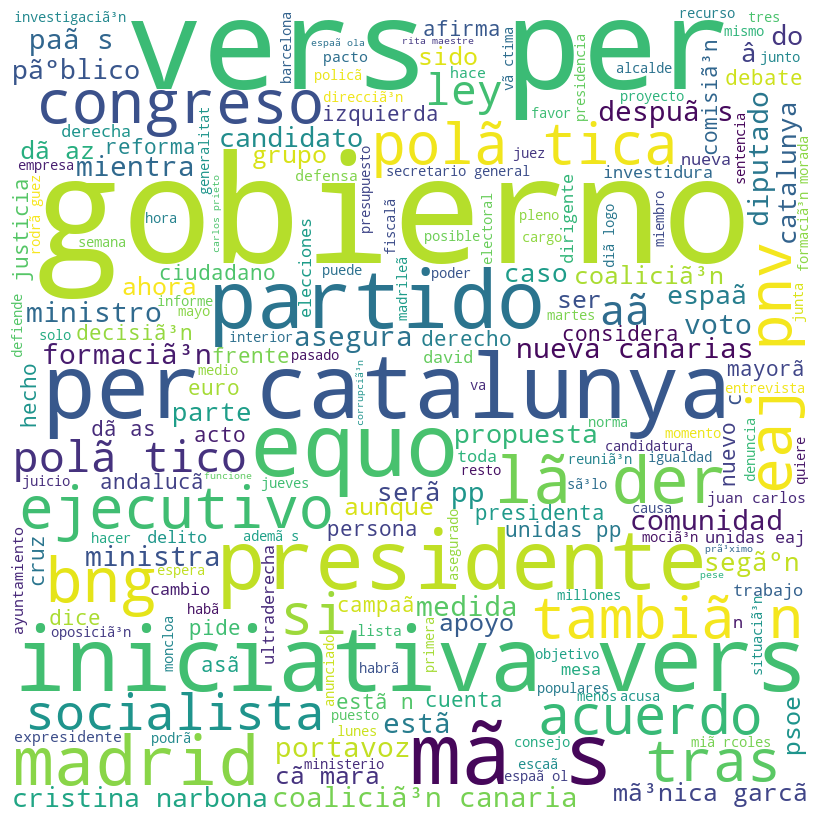

---------- Words for class: 1 ----------


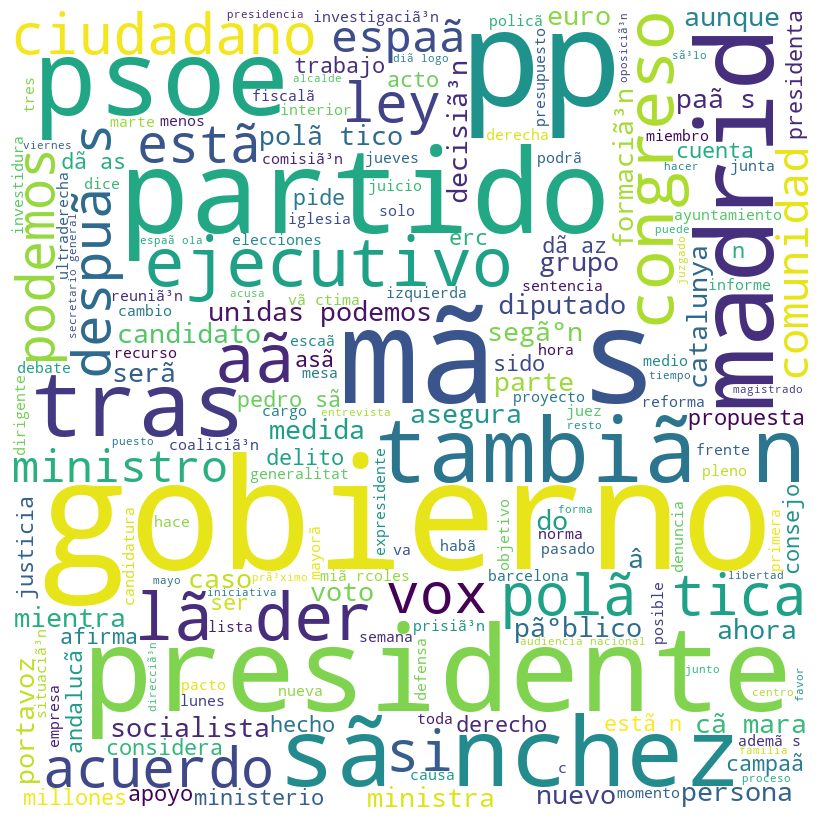

In [13]:
for i in range(2):
    print(f"---------- Words for class: {i} ----------")
    show_wordcloud(train.loc[train["Label"] == (i), "Descripcion"], stopwords=STOPWORDS)

In [15]:
df

,Label,Titulo,Descripcion
0,1,Moreno intenta apaciguar el flanco sanitario m...,El presidente abre la puerta a unos comicios e...
1,1,La AbogacÃ­a del Estado se retira como acusaci...,"En un escrito, la abogada del Estado Rosa MarÃ..."
2,0,Las promesas incumplidas de Pablo Echenique en...,Este lunes y martes la Asamblea de Madrid acog...
3,1,SÃ¡nchez defiende 'resolver el problema' de la...,Resulta evidente que la ley ha tenido algunos ...
4,1,Ian Gibson cierra la lista electoral de la con...,"El hispanista, que ya ocupÃ³ un puesto simbÃ³l..."
...,...,...,...
57226,0,MÃ³nica GarcÃ­a: 'La ultraderecha ya no nos se...,El lÃ­der de PP abandona el debate de la Caden...
57227,1,Sigue aquÃ­ la comparecencia de Luis BÃ¡rcenas...,Luis BÃ¡rcenas comparece en la comisiÃ³n del C...
57228,0,Albiol recupera la alcaldÃ­a de Badalona tras ...,Desde Guanyem rechazaron dividirse a partes ig...
57229,1,El mando de la Guardia Civil que reconociÃ³ to...,Exteriores revela que el teniente coronel Pedr...


In [16]:
nltk.download("stopwords")
spanish_stopwords = stopwords.words("spanish")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\erich\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

X = df[['Titulo', 'Descripcion']]
y = df["Label"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=77
)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=77
)

tfidf_vectorizer = TfidfVectorizer(max_features=100)

X_train_vectorized = tfidf_vectorizer.fit_transform(X_train)
X_test_vectorized = tfidf_vectorizer.transform(X_test)

n_features_vectorized = X_train_vectorized.shape[1]

n_components_to_fit = n_features_vectorized

if n_features_vectorized == 0:
    n_components_to_fit = 1

svd_analysis = TruncatedSVD(n_components=n_components_to_fit, algorithm='randomized', random_state=42)

svd_analysis.fit(X_train_vectorized)

explained_variance_ratio = svd_analysis.explained_variance_ratio_

cumulative_explained_variance = np.cumsum(explained_variance_ratio)

for threshold in [0.80, 0.85, 0.95]:
    if cumulative_explained_variance[-1] < threshold:
         n_components_for_threshold = len(cumulative_explained_variance)
         print(f"To explain at least {threshold:.2f} variance, you might need more than {n_components_for_threshold} components.")
    else:
        n_components_for_threshold = np.argmax(cumulative_explained_variance >= threshold) + 1
        print(f"To explain at least {threshold:.2f} variance, you need {n_components_for_threshold} components.")

To explain at least 0.80 variance, you need 2 components.
To explain at least 0.85 variance, you need 2 components.
To explain at least 0.95 variance, you need 2 components.


In [49]:


preprocessor = make_column_transformer(
    (TfidfVectorizer(stop_words=spanish_stopwords), 'Titulo'),
    (TfidfVectorizer(stop_words=spanish_stopwords), 'Descripcion'),
    remainder='passthrough'
)

pipeline_svd = Pipeline(
    [
        ("preprocessor", preprocessor),            
        ("svd", TruncatedSVD(random_state=77)),     
        ("gnb", GaussianNB()),                      
    ]
)

param_space_svd = {
    "gnb__var_smoothing": Real(1e-9, 1e-3, prior="log-uniform"),
    "preprocessor__tfidfvectorizer-1__max_features": Integer(50, 1000),
    "preprocessor__tfidfvectorizer-2__max_features": Integer(50, 1000), 
    "svd__n_components": Integer(2, 7, prior='uniform'),             
}


opt_svd = BayesSearchCV(
    pipeline_svd,
    search_spaces=param_space_svd,
    n_iter=4,
    cv=3,
    scoring="recall",
    random_state=77,
    verbose=10,
)

print("Starting Bayesian search with Truncated SVD...")
opt_svd.fit(X_train, y_train)


print("\n--- Results with Truncated SVD ---")
print("Best parameters: ", opt_svd.best_params_)
print("\nTest set performance:")
y_pred_svd = opt_svd.predict(X_test)
print(confusion_matrix(y_test, y_pred_svd))
print(classification_report(y_test, y_pred_svd))

Starting Bayesian search with Truncated SVD...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3; 1/1] START gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7
[CV 1/3; 1/1] END gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7;, score=0.936 total time=   1.4s
[CV 2/3; 1/1] START gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7
[CV 2/3; 1/1] END gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7;, score=0.950 total time=   1.3s
[CV 3/3; 1/1] START gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__m

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

Reporte de metricas


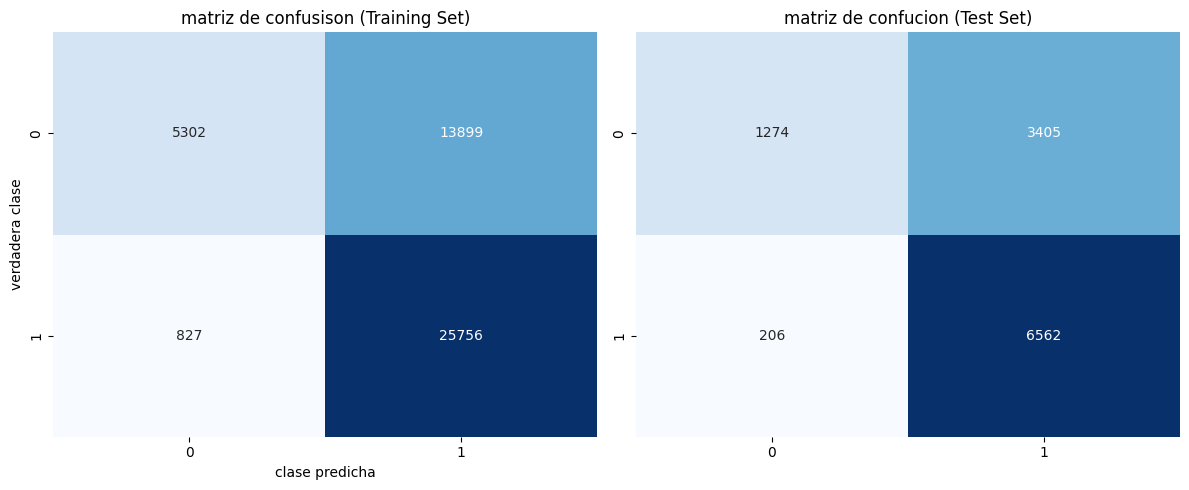


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.87      0.28      0.42     19201
           1       0.65      0.97      0.78     26583

    accuracy                           0.68     45784
   macro avg       0.76      0.62      0.60     45784
weighted avg       0.74      0.68      0.63     45784


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.86      0.27      0.41      4679
           1       0.66      0.97      0.78      6768

    accuracy                           0.68     11447
   macro avg       0.76      0.62      0.60     11447
weighted avg       0.74      0.68      0.63     11447



In [ ]:

y_train_pred = opt_svd.predict(X_train)
y_test_pred = opt_svd.predict(X_test)


print("Reporte de metricas")

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

classes = np.unique(y_train)
class_labels = [str(c) for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_xlabel('clase predicha')
axes[0].set_ylabel('verdadera clase')
axes[0].set_title('matriz de confusison (Training Set)')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_xlabel('clase predicha')
axes[0].set_ylabel('verdadera clase')
axes[1].set_title('matriz de confucion (Test Set)')

plt.tight_layout()
plt.show()

print("\n Reporte de clasificacion (Entrenamiento):")
print(classification_report(y_train, y_train_pred))

print("\n Reporte de clasificacion (Test):")
print(classification_report(y_test, y_test_pred))

In [30]:
X_train

['Is this the first document?',
 'This is the first document.',
 'And this is the third document.']

In [53]:


preprocessor = make_column_transformer(
    (TfidfVectorizer(stop_words=spanish_stopwords), 'Titulo'),
    (TfidfVectorizer(stop_words=spanish_stopwords), 'Descripcion'),
    remainder='passthrough'
)

pipeline_svd = Pipeline(
    [
        ("preprocessor", preprocessor),            
        ("svd", TruncatedSVD(random_state=77)),     
        ("gnb", GaussianNB()),                      
    ]
)

param_space_svd = {
    "gnb__var_smoothing": Real(1e-9, 1e-3, prior="log-uniform"),
    "preprocessor__tfidfvectorizer-1__max_features": Integer(50, 1000),
    "preprocessor__tfidfvectorizer-2__max_features": Integer(50, 1000), 
    "svd__n_components": Integer(2, 7, prior='uniform'),             
}


opt_svd = BayesSearchCV(
    pipeline_svd,
    search_spaces=param_space_svd,
    n_iter=4,
    cv=3,
    scoring="f1_weighted",
    random_state=77,
    verbose=10,
)

print("Starting Bayesian search with Truncated SVD...")
opt_svd.fit(X_train, y_train)


print("\n--- Results with Truncated SVD ---")
print("Best parameters: ", opt_svd.best_params_)
print("\nTest set performance:")
y_pred_svd = opt_svd.predict(X_test)
print(confusion_matrix(y_test, y_pred_svd))
print(classification_report(y_test, y_pred_svd))

Starting Bayesian search with Truncated SVD...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3; 1/1] START gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7
[CV 1/3; 1/1] END gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7;, score=0.638 total time=   1.4s
[CV 2/3; 1/1] START gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7
[CV 2/3; 1/1] END gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__max_features=651, preprocessor__tfidfvectorizer-2__max_features=463, svd__n_components=7;, score=0.652 total time=   1.3s
[CV 3/3; 1/1] START gnb__var_smoothing=1.097287379314942e-06, preprocessor__tfidfvectorizer-1__m


--- Metrics Report ---


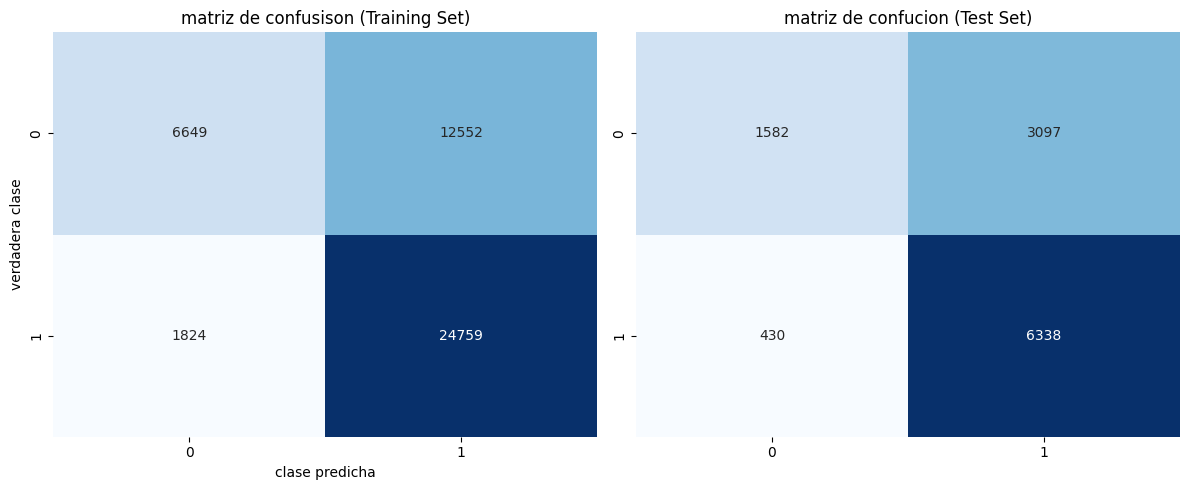


 Reporte de clasificacion (Entrenamiento):
              precision    recall  f1-score   support

           0       0.78      0.35      0.48     19201
           1       0.66      0.93      0.78     26583

    accuracy                           0.69     45784
   macro avg       0.72      0.64      0.63     45784
weighted avg       0.71      0.69      0.65     45784


 Reporte de clasificacion (Test):
              precision    recall  f1-score   support

           0       0.79      0.34      0.47      4679
           1       0.67      0.94      0.78      6768

    accuracy                           0.69     11447
   macro avg       0.73      0.64      0.63     11447
weighted avg       0.72      0.69      0.66     11447



In [54]:

y_train_pred = opt_svd.predict(X_train)
y_test_pred = opt_svd.predict(X_test)

print("\n--- Metrics Report ---")

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

classes = np.unique(y_train)
class_labels = [str(c) for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_xlabel('clase predicha')
axes[0].set_ylabel('verdadera clase')
axes[0].set_title('matriz de confusison (Training Set)')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_xlabel('clase predicha')
axes[0].set_ylabel('verdadera clase')
axes[1].set_title('matriz de confucion (Test Set)')

plt.tight_layout()
plt.show()

print("\n Reporte de clasificacion (Entrenamiento):")
print(classification_report(y_train, y_train_pred))

print("\n Reporte de clasificacion (Test):")
print(classification_report(y_test, y_test_pred))